<a href="https://colab.research.google.com/github/NoDanCoder/AirBnB_clone/blob/master/Semana4/Interpolacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

In [19]:
X = np.array([1,2,3,4])
Y = np.array([0,2.5,1,4])

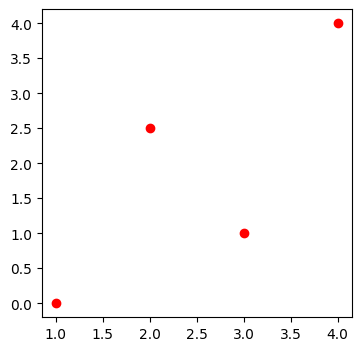

In [20]:
fig = plt.figure(figsize=(4,4))
plt.scatter(X,Y,color='red')

In [21]:
def Lagrange( x, X, i ):

  L = 1
  for j in range(len(X)):
    if i != j:
      L *= (x-X[j])/(X[i]-X[j])
  return L

In [22]:
# Definir un simbolo
x= sym.Symbol('x',real=True)
x

x

In [23]:
L0 = Lagrange(x,X,0)#.expand()
L0

(4/3 - x/3)*(3/2 - x/2)*(2 - x)

In [24]:
L1 = Lagrange(x,X,1)#.expand()
L1

(2 - x/2)*(3 - x)*(x - 1)

In [25]:
def Interpolate(x,X,Y):

  Poly = 0.
  for i in range(len(X)):
    Poly += Y[i]*Lagrange(x,X,i)

  return Poly

In [26]:
# Generar un soporte de ploteo
x1 = np.linspace(np.min(X),np.max(X),100)
y1 = Interpolate(x1,X,Y)

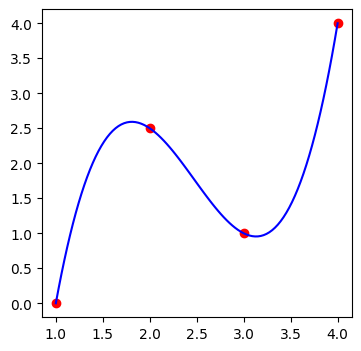

In [27]:
fig = plt.figure(figsize=(4,4))
plt.scatter(X,Y,color='red')
plt.plot(x1,y1,color='blue')

In [28]:
Interpolate(x,X,Y).expand()

1.41666666666667*x**3 - 10.5*x**2 + 24.0833333333333*x - 15.0

In [29]:
y2 = np.zeros_like(x1)
y3 = np.zeros_like(x1)
for i in range(len(x1)):
  y2[i] = Lagrange(x1[i],X,0)
  y3[i] = Lagrange(x1[i],X,1)


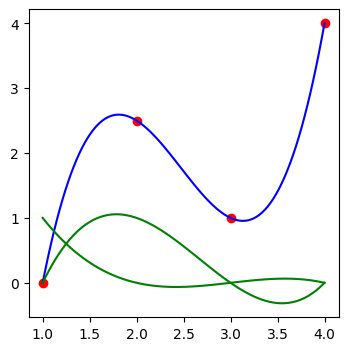

In [30]:
fig = plt.figure(figsize=(4,4))
plt.scatter(X,Y,color='red')
plt.plot(x1,y1,color='blue')
plt.plot(x1,y2,color='green')
plt.plot(x1,y3,color='green')

In [34]:
def derivative(x,f,h=1e-6):
  return (f(x+h)-f(x-h))/(2*h)

In [32]:
def newton(f,df,xn,itmax=1000,precision=1e-10):

  error = 1
  it = 0

  while error > precision and it < itmax:

    try:
      xn1 = xn - f(xn)/df(xn,f)
      error = np.abs( xn1 - xn )
    except ZeroDivisionError:
      print('Division por zero')
      break

    xn = xn1
    it += 1

  if it == itmax:
    return False
  else:
    #print(it)
    return xn